# 从0实现RNN

## 加载时间机器数据集

定义见之前的文件

In [7]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)  # 返回一个迭代器，每次读一个小批量，再返回一个字典变量主要是实现:index to token

c:\Users\20249\.conda\envs\test1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## one-hot 编码

目标位置置0，其余位置置1

In [3]:
F.one_hot(torch.tensor([0, 2]), len(vocab))  # 这里的len调用的函数是时间机器里面词元的种类数，一共是28（26个音文字母+空格+unk词元）

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]])

### 小批量数据的形状

形状为（批量大小，时间步数）

In [9]:
X = torch.arange(10).reshape((2, 5))
F.one_hot(X.T, 28).shape

torch.Size([5, 2, 28])

这里为什么要转置X？

RNN中，我们的更新是基于时间步的：我们想获得形状为 （时间步数，批量大小，词表大小）的输出。 这将使我们能够更方便地通过最外层的维度， 一步一步地更新小批量数据的隐状态

## 初始化RNN参数

In [6]:
# 返回需要学习的参数
def get_params(vocab_size, num_hiddens, device):  # vocab_size是词表大小，num_hiddens是隐藏层维度
    num_inputs = num_outputs = vocab_size  # 输入，输出经过one-hot编码之后变成了一个长度为vocab_size长度的向量

    def normal(shape):  # 辅助函数，在gpu上生成一个均值为0，标准差为0.01的随机数张量
        return torch.randn(size=shape, device=device) * 0.01

    # 隐藏层参数
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)  # 每一个隐藏元的偏置
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)  # 为每个参数附加梯度计算梯度更新
    return params

## 循环神经网络模型

初始化时返回隐藏状态：放到一个元组（tuple）里面

In [5]:
def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )  # 后面在LSTM中有两个隐藏状态，所以这里先用tuple写

定义RNN计算在一个时间步内计算隐藏状态和输出

In [20]:
def rnn(inputs, state, params):  # 这里其实是前向传播函数
    # inputs的形状：(时间步数量，批量大小，词表大小)
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    # X的形状：(批量大小，词表大小)
    for X in inputs:  # 沿着第一个维度去遍历，前面转置了，是按照时间步去算的
#       print(f"当前状态下H的形状是{H.shape}")
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h) # 得到当前时间步的隐藏状态（也是一种更新）
#shape
#X:(time_steps, batch_size, vocab_size);W_xh:(vocab_size, num_hiddens);H(batch_size, num_hiddens); w_hh:(num_hiddens, num_hiddens)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)  # cat在0维度，列数没变（vocab_size），行数变为时间步数量*批量大小

创建一个类来包装如下函数

In [3]:
class RNNModelScratch: 
    """从零开始实现的循环神经网络模型"""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn  # init_state初始化隐藏状态，forward_fn表示前向传播函数

    def __call__(self, X, state):  # 魔术方法，允许直接调用
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)  # 初始化隐藏状态

检查输出是否有正确的形状

In [21]:
num_hiddens = 512
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                      init_rnn_state, rnn)  # 这里的rnn实则是前面定义的前向传播函数
state = net.begin_state(X.shape[0], d2l.try_gpu())  # 这里的X是之前定义的一个2*5的矩阵，state得到的是隐藏层的初始状态
Y, new_state = net(X.to(d2l.try_gpu()), state)  # 这里是直接用了call方法
Y.shape, len(new_state), new_state[0].shape

(torch.Size([10, 28]), 1, torch.Size([2, 512]))

解释一下上面的代码：
1. state表示的是隐藏层的初始状态，是一个元组，其形状是：(batch_size, num_hiddens)
2. Y表示的是输出层的对应输出，对应RNNModelScratch中的call方法：
```
X = F.one_hot(X.T, self.vocab_size).type(torch.float32) # 先转置X，再使用one-hot编码，最终得到的shape是(time_steps, batch_size, vocab_size),这里对应的是(5, 2, 28)
return self.forward_fn(X, state, self.params)  # 这里得到的是输出Y：shape is (time_steps*batch_size, vocab_size),隐藏层的输出是（H， ）得到的是一个tuple，所以取len为1,而隐藏层的形状为(batch_size, num_hiddens)
```
$$H_t = \phi(X_t W_{xh} + H_{t-1} W_{hh} + b_h)$$

## 定义预测函数生成后续的字符
先讲预测再讲训练

In [ ]:
def predict_ch8(prefix, num_preds, net, vocab, device):  # 依次是：当前已经预测的token列表，需要生成的token数量，定义的网络对象，map对象，GPU
    """在prefix后面生成新字符"""
    state = net.begin_state(batch_size=1, device=device)  # 初始的隐藏状态，表示对一个字符做预测
    outputs = [vocab[prefix[0]]]  # 第一个token的下标，放到output列表中
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1)) # get_input函数存下最近预测的词作为当前时刻的输入
    for y in prefix[1:]:  # 预热期
        _, state = net(get_input(), state) # 更新已知序列的隐藏状态，不care输出，这里一直更新到当前时间步的隐藏状态,这里调用的net相当于是前向传播一步
        outputs.append(vocab[y])  # 把当前token的下标也放到output列表中
    for _ in range(num_preds):  # 预测num_preds步
        y, state = net(get_input(), state) # y是one-hot编码之后的向量，其shape是(1, vocab_size)
        outputs.append(int(y.argmax(dim=1).reshape(1))) # 取y中概率最大的那个，作为当前预测的token的下标
    return ''.join([vocab.idx_to_token[i] for i in outputs]) # 使用空字符join起来并进行输出



测试一下：


In [ ]:
predict_ch8('time traveller', 10, net, vocab, d2l.try_gpu())  # 还没训练的，瞎猜的

'time travellerjddayjdday'

## 梯度剪裁函数
$$\mathbf{g} \leftarrow \min\left(1, \frac{\theta}{\Vert{}\mathbf{g}\Vert{}} \right) \mathbf{g}$$

In [24]:
def grad_clipping(net, theta):  #@save
    """裁剪梯度"""
    if isinstance(net, nn.Module):  # 拿到所有层的可以参与训练的函数
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))  # 把所有层的梯度全部求和，这里相当于求取||g||
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm  # 做一次投影

## 训练函数
定义一个函数在一个迭代周期内进行训练

困惑度：
$$
\frac{1}{n} \sum_{t=1}^{n} -logP(x_t|x_{t-1}, \ldots, x_1)
$$

In [ ]:
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):  # use_random_iter 是否使用随机抽样
    """训练网络一个迭代周期（定义见第8章）"""
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  # 训练损失之和,词元数量
    for X, Y in train_iter:
        if state is None or use_random_iter:  # 这里对随机抽样有一个处理，因为如果是随机抽样的话，每一个batch都需要去初始化隐藏状态，因为随机抽样抽出来的文本数据不是时序的
            # 在第一次迭代或使用随机抽样时初始化state
            state = net.begin_state(batch_size=X.shape[0], device=device)  # 初始化隐藏状态
        else:  # 针对顺序抽样而且不是第一次开始迭代的情况，不会去做重新的初始化，这里在做完一个batch迭代的时候，我们需要断开梯度，不然每一个time_step的梯度都会累加
            if isinstance(net, nn.Module) and not isinstance(state, tuple):  # net是一个nn.Module模型，state只有一个隐状态，直接剥离计算图即可，_表示是原地操作
                state.detach_()
            else:
                # state对于nn.LSTM或对于我们从零开始实现的模型是个张量
                for s in state:
                    s.detach_()
# Y 是一个batch_size * num_steps的矩阵，这里需要先转置再展平；因为RNN中的前向传播时按照time_step推进的；reshape(-1)对于二维矩阵来说，是按行拼接的
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()   # loss角度上面来说，本质上就是一个多分类问题
# 这里用y.long()是因为防止报错，因为PyTorch 对分类任务有一个死规定——分类的真实标签（即类别编号）必须是 64位整数
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step() # 前向传播，更新参数
        else:
            l.backward()
            grad_clipping(net, 1)
            # loss中已经取平均值了，所以这里不用再除以y.numel()了
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()  # 返回的是困惑度和训练速度

从0开始进行训练：

In [ ]:
#@save
def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    loss = nn.CrossEntropyLoss()  # 定义交叉熵损失函数
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)  # 需要在函数里面经常调用，做lambda表达式
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)  # 预测后面50个词元
    # 训练和预测
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

现在，我们训练循环神经网络模型。 因为我们在数据集中只使用了10000个词元， 所以模型需要更多的迭代周期来更好地收敛

困惑度 1.0, 52036.7 词元/秒 cuda:0
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


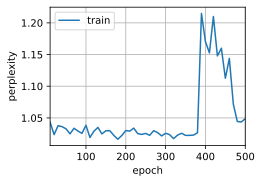

In [28]:
num_epochs, lr = 500, 1
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())  # 这里相当于把整本书记住了

看一下随机抽样的结果：

困惑度 1.3, 44834.6 词元/秒 cuda:0
time traveller held in his hand was a glitteringmetallic framewo
traveller held in his hand was a glitteringmetallic framewo


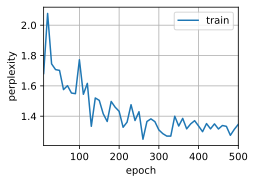

In [29]:
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu(), use_random_iter=True)  # 随机抽样